# 01 Dataset Analysis and Preprocessing
This notebook reviews the saved dataset splits and preprocessing artifacts. It does not regenerate splits or retrain models.

## Project Overview
The project classifies Urdu tweets as Negative, Neutral, or Positive while preventing emoji-based label leakage.

## Dataset Description
SentiUrdu-1M contains weakly supervised labels. The analysis below uses the immutable CSV files in `data/splits/` and summaries in `outputs/results/`.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RESULTS = ROOT / 'outputs' / 'results'
SPLITS = ROOT / 'data' / 'splits'

split_summary = json.loads((RESULTS / 'split_summary.json').read_text(encoding='utf-8'))
label_summary = json.loads((RESULTS / 'label_mapping_summary.json').read_text(encoding='utf-8'))
train = pd.read_csv(SPLITS / 'train.csv', encoding='utf-8')
validation = pd.read_csv(SPLITS / 'validation.csv', encoding='utf-8')
test = pd.read_csv(SPLITS / 'test.csv', encoding='utf-8')
print(f"Loaded {len(train):,} train, {len(validation):,} validation, and {len(test):,} test rows.")

Loaded 362,576 train, 77,695 validation, and 77,695 test rows.


## Loaded Split Summary
The saved summary is checked against the loaded CSV row counts so reviewers can verify that the notebook is using the final project artifacts.

In [2]:
split_table = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Rows from CSV': [len(train), len(validation), len(test)],
    'Rows from summary': [split_summary['train_size'], split_summary['validation_size'], split_summary['test_size']],
})
split_table

,Split,Rows from CSV,Rows from summary
0,Train,362576,362576
1,Validation,77695,77695
2,Test,77695,77695


## Class Distribution
The same severe Positive-class dominance appears in every stratified split.

,Train,Validation,Test
task_label,,,
Negative,48980,10495,10496
Neutral,999,214,214
Positive,312597,66986,66985


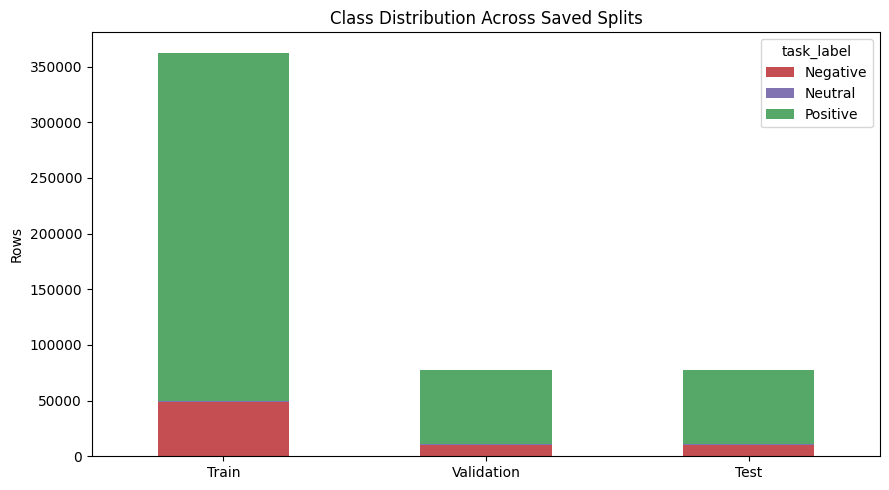

In [3]:
distribution = pd.DataFrame({
    'Train': train['task_label'].value_counts(),
    'Validation': validation['task_label'].value_counts(),
    'Test': test['task_label'].value_counts(),
}).fillna(0).astype(int).reindex(['Negative', 'Neutral', 'Positive'])
display(distribution)
distribution.T.plot(kind='bar', stacked=True, figsize=(9, 5), color=['#c44e52', '#8172b2', '#55a868'])
plt.title('Class Distribution Across Saved Splits')
plt.ylabel('Rows')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Label Imbalance
Percentages reveal why accuracy alone is not an adequate selection metric: Neutral is far below one percent of the filtered dataset.

,Rows,Percentage
Negative,69971,13.509%
Neutral,1427,0.276%
Positive,446568,86.216%


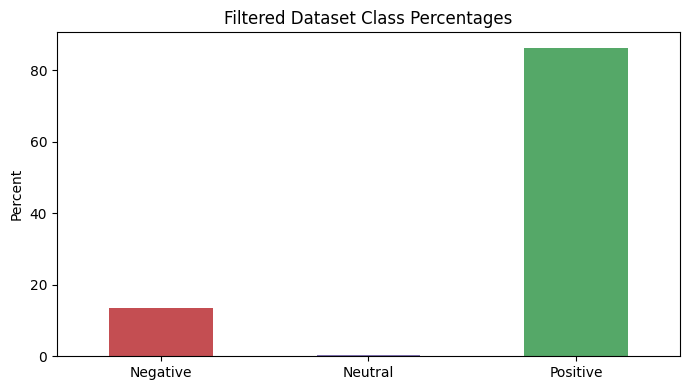

In [4]:
overall = pd.Series(split_summary['class_distribution_before_split'], name='Rows').reindex(['Negative', 'Neutral', 'Positive'])
imbalance = overall.to_frame()
imbalance['Percentage'] = imbalance['Rows'] / imbalance['Rows'].sum() * 100
display(imbalance.style.format({'Percentage': '{:.3f}%'}))
imbalance['Percentage'].plot(kind='bar', figsize=(7, 4), color=['#c44e52', '#8172b2', '#55a868'])
plt.title('Filtered Dataset Class Percentages')
plt.ylabel('Percent')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Preprocessing Pipeline
The saved splits contain `raw_text` and `clean_text`. Cleaning normalizes Unicode, removes URLs and mentions, preserves hashtag text, removes numbers and punctuation, removes emojis, and normalizes whitespace.

In [5]:
sample_columns = ['raw_text', 'clean_text', 'task_label', 'text_length']
sample = train.loc[train['raw_text'].astype(str) != train['clean_text'].astype(str), sample_columns].head(8)
pd.set_option('display.max_colwidth', 120)
sample

,raw_text,clean_text,task_label,text_length
0,آنی دیا او دھروں کال نئ کتا مار گڈی آندی ہے جیڑی کے آن والی ہے بس 😋,آنی دیا او دھروں کال نئ کتا مار گڈی آندی ہے جیڑی کے آن والی ہے بس,Positive,17
1,اگر کوئی الیکٹریشن کسی کیلئے ایک تار غلط لگوا دے دوسری بار لوگ فری میں بھی کام نہیں کرواتے اس سے اور کچھ لوگ تین بار...,اگر کوئی الیکٹریشن کسی کیلئے ایک تار غلط لگوا دے دوسری بار لوگ فری میں بھی کام نہیں کرواتے اس سے اور کچھ لوگ تین بار...,Positive,47
2,شوق وفا نہ سہی خوف خدا تو رکھ😕,شوق وفا نہ سہی خوف خدا تو رکھ,Negative,8
3,جلال آپکے فوراً شعر آنے کا راز بھی پتہ ہے بتا دوں😂,جلال آپکے فوراً شعر آنے کا راز بھی پتہ ہے بتا دوں,Positive,12
4,اسی لئے اب تک کی ساری تقرر انہی کے متعلقہ تھی😂,اسی لئے اب تک کی ساری تقرر انہی کے متعلقہ تھی,Positive,11
5,ویسے تمہارا پوچھنا بنتا بھی 😂😂👊👊,ویسے تمہارا پوچھنا بنتا بھی,Positive,5
6,شاید درست کہا کیونکہ اتنی تیز روشنی میں آنکھوں پر کالی پٹی باندھ کر بھی سونے کی کوشش کرو گے تو نیند نہیں آۓ گی پلس ت...,شاید درست کہا کیونکہ اتنی تیز روشنی میں آنکھوں پر کالی پٹی باندھ کر بھی سونے کی کوشش کرو گے تو نیند نہیں آۓ گی پلس ت...,Positive,31
7,آپ نے گھبرانا نہیں ہے 😂 یو ٹرن لے لے کر خان صاحب کی قمر ٹوٹ گئی ہے 😂,آپ نے گھبرانا نہیں ہے یو ٹرن لے لے کر خان صاحب کی قمر ٹوٹ گئی ہے,Positive,17


## Leakage Prevention
Emoji removal is essential because source labels were influenced by emoji heuristics. Keeping emojis as features would leak information from the weak-labeling process into evaluation.

## Key Dataset Findings
The final filtered dataset has 517,966 rows and reproducible 70/15/15 stratified splits. Positive dominates, Negative is substantially smaller, and Neutral is extremely scarce. Macro-F1 and per-class F1 are therefore required alongside accuracy.